<a href="https://colab.research.google.com/github/bbombver/BSC_DPDM2025/blob/main/ch5_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## DATAset

In [ ]:
from sklearn.datasets import load_digits

dagits = load_digits()
X,y = dagits.data, dagits.target

print(f"Shape of data (X): {X.shape}")
print(f"Shape of target (y): {y.shape}")
print(f"Number of classes: {len(dagits.target_names)}")
print(f"First 5 target labels: {y[:5]}")

Shape of data (X): (1797, 64)
Shape of target (y): (1797,)
Number of classes: 10
First 5 target labels: [0 1 2 3 4]


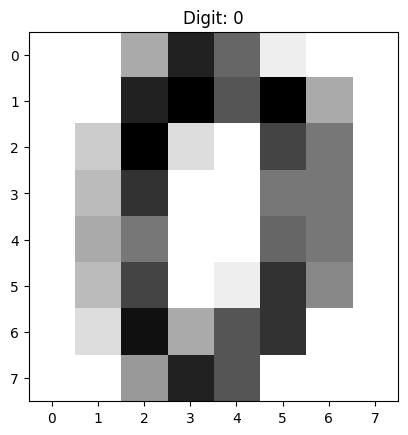

In [ ]:
import matplotlib.pyplot as plt

image_data = X[0] # Assign the image data from X
image_label = y[0] # Assign the label from y

image_reshaped = image_data.reshape((8, 8))

plt.imshow(image_reshaped, cmap=plt.cm.gray_r, interpolation='nearest')
plt.title(f"Digit: {image_label}") # Use image_label for the title
plt.show()

In [ ]:
import pandas as pd

df = pd.DataFrame(dagits.data)

df['taeget'] = dagits.target
print("DataFram created successfuly with shape:",df.shape)

DataFram created successfuly with shape: (1797, 65)


In [ ]:
df.head()

,0,1,2,3,4,5,6,7,8,9,...,55,56,57,58,59,60,61,62,63,taeget
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0,0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0,1
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0,2
3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0,...,0.0,0.0,0.0,7.0,13.0,13.0,9.0,0.0,0.0,3
4,0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2.0,16.0,4.0,0.0,0.0,4


In [ ]:
X.shape

(1797, 64)

In [ ]:
X_train = X[:1700]
y_train = y[:1700]
X_test = X[1700:]
y_test = y[1700:]

# Model construction
- import
- define (hyper-parameters)
- train
- evaluate

# import

In [ ]:
from sklearn.tree import DecisionTreeClassifier

# define

In [ ]:
tree0 = DecisionTreeClassifier(random_state=6)

# Training

In [ ]:
tree0.fit(X_train,y_train)

DecisionTreeClassifier(random_state=6)

Text(0.5, 1.0, 'Decison Tree Classifier for Dagits Dataset')

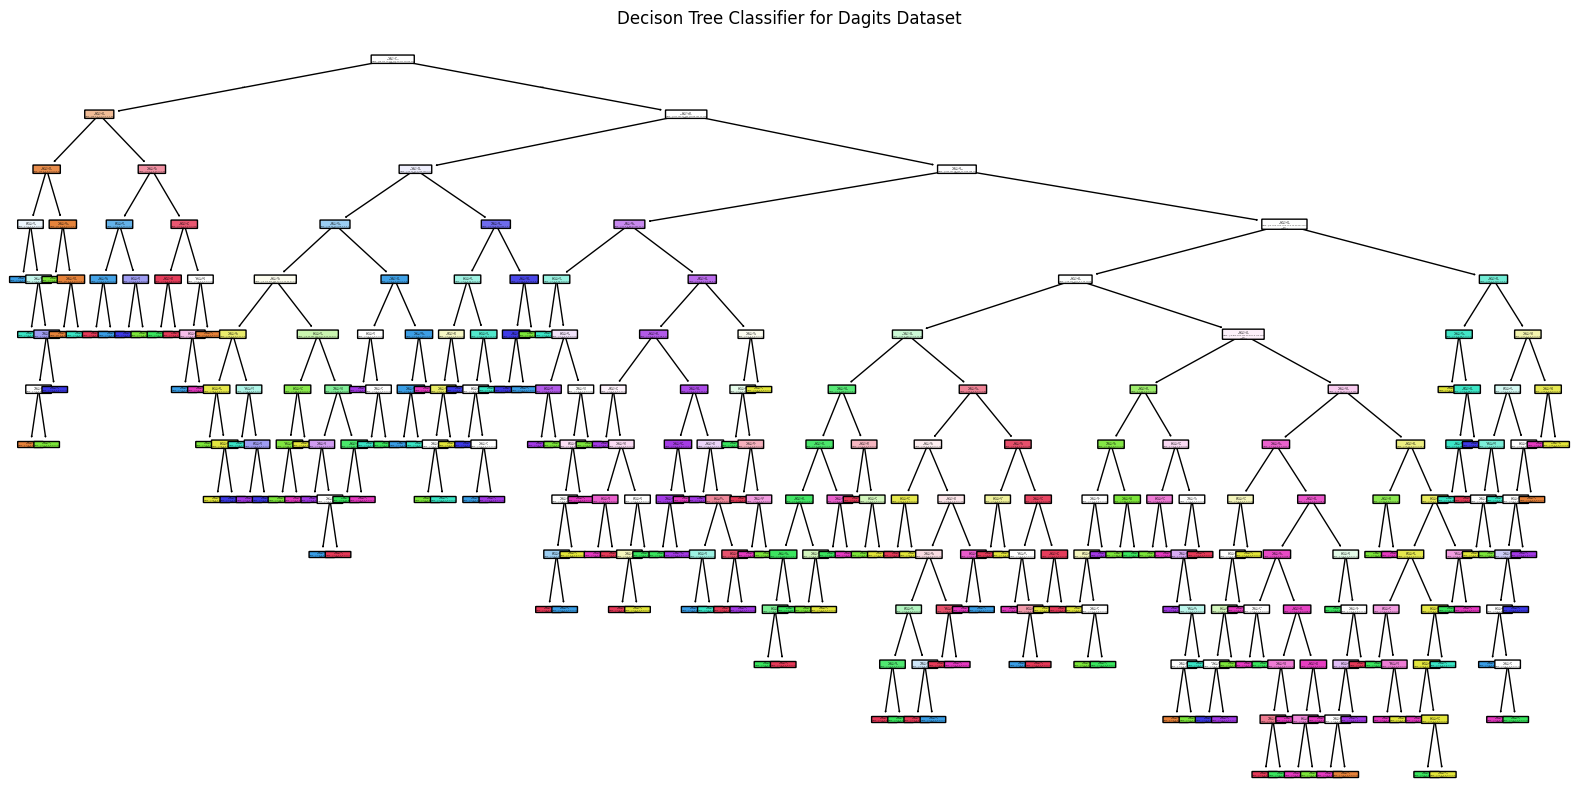

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20,10))
plot_tree(tree0,filled=True,rounded=True,class_names=dagits.target_names.astype(str))
plt.title("Decison Tree Classifier for Dagits Dataset")

# Evaluate

In [ ]:
y_predict = tree0.predict(X_test)

In [ ]:
y_predict

array([8, 6, 5, 0, 9, 8, 9, 8, 4, 1, 7, 7, 9, 5, 1, 0, 0, 6, 2, 7, 8, 2,
       0, 3, 8, 6, 8, 8, 7, 4, 3, 4, 6, 6, 6, 4, 9, 1, 9, 0, 9, 6, 7, 8,
       2, 0, 0, 6, 7, 6, 8, 2, 1, 7, 4, 6, 3, 1, 2, 9, 1, 7, 6, 8, 4, 8,
       1, 4, 0, 5, 5, 6, 9, 6, 1, 7, 5, 4, 4, 7, 2, 5, 2, 2, 5, 7, 9, 4,
       4, 3, 3, 4, 9, 0, 8, 9, 8])

In [ ]:
y_test

array([5, 6, 5, 0, 9, 8, 9, 8, 4, 1, 7, 7, 3, 5, 1, 0, 0, 2, 2, 7, 8, 2,
       0, 1, 2, 6, 3, 3, 7, 3, 3, 4, 6, 6, 6, 4, 9, 1, 5, 0, 9, 5, 2, 8,
       2, 0, 0, 1, 7, 6, 3, 2, 1, 7, 4, 6, 3, 1, 3, 9, 1, 7, 6, 8, 4, 3,
       1, 4, 0, 5, 3, 6, 9, 6, 1, 7, 5, 4, 4, 7, 2, 8, 2, 2, 5, 7, 9, 5,
       4, 8, 8, 4, 9, 0, 8, 9, 8])

In [ ]:
from sklearn.metrics import accuracy_score

In [ ]:
accuracy_score(y_test, y_predict)

0.7938144329896907

## Pre-pruning (hyper-parameter tuning)

In [ ]:
from sklearn.tree import DecisionTreeClassifier #import
tree1 = DecisionTreeClassifier(random_state=6, max_depth=3) #define
tree1.fit(X_train,y_train) #train


DecisionTreeClassifier(max_depth=3, random_state=6)

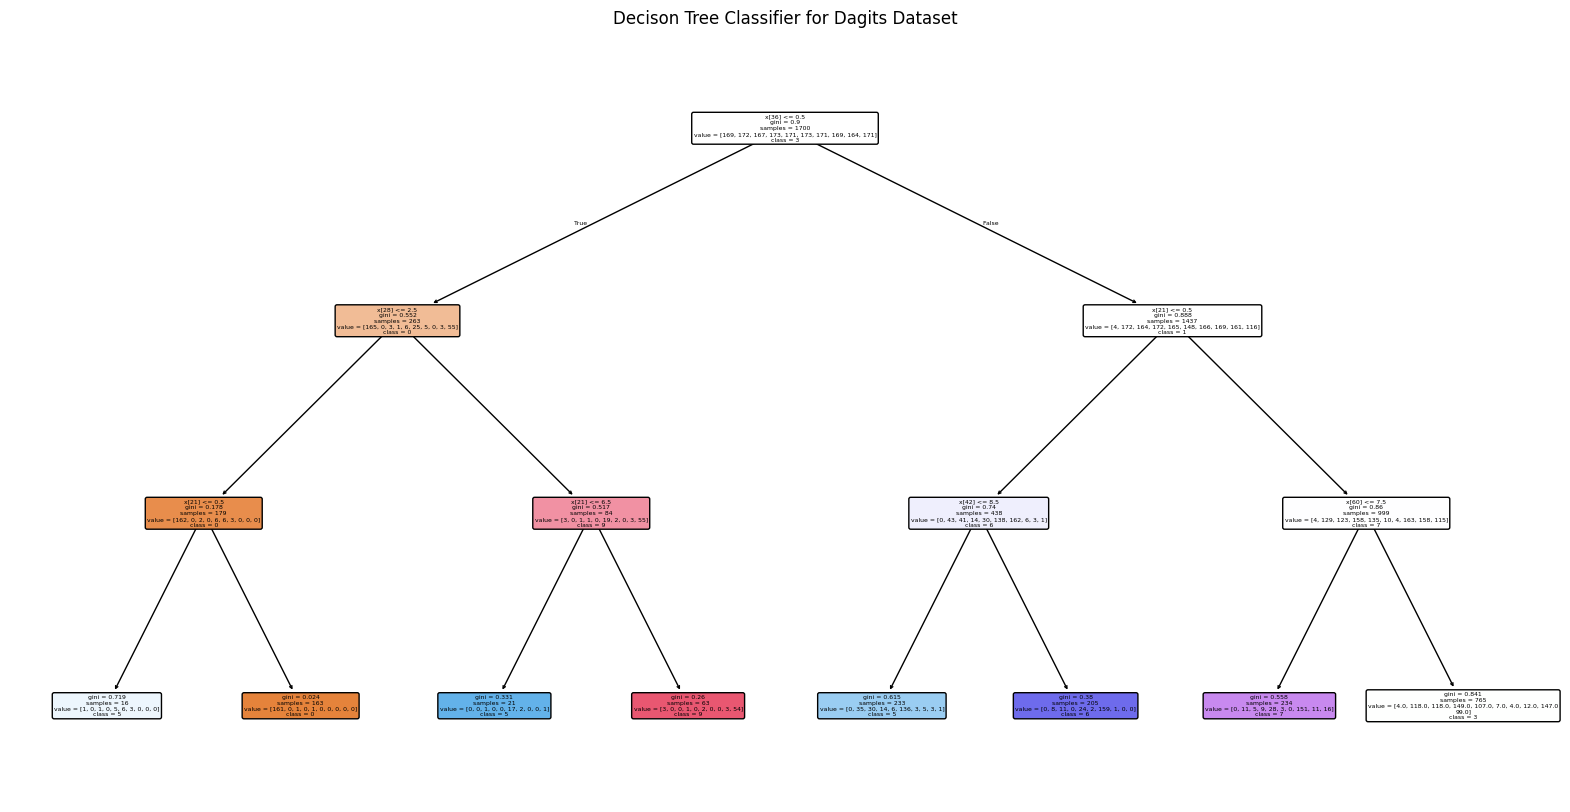

In [ ]:
plt.figure(figsize=(20,10))
plot_tree(tree1,filled=True,rounded=True,class_names=dagits.target_names.astype(str))
plt.title("Decison Tree Classifier for Dagits Dataset")
plt.show()

## Evaluate

In [ ]:
y_predict1 = tree1.predict(X_test)
accuracy_score(y_test,y_predict1)

0.4639175257731959

## Tree2

In [ ]:
from sklearn.tree import DecisionTreeClassifier #import
tree2 = DecisionTreeClassifier(random_state=6, max_depth=7) #
tree2.fit(X_train,y_train) #train
y_predict2 = tree2.predict(X_test)
accuracy_score(y_test,y_predict2)


0.7938144329896907

# Quiz 11 tune hyper-parameters so that the accuracy is better than default(at random_state=6)

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

tree_best = DecisionTreeClassifier(random_state=5, max_depth=10)
tree_best.fit(X_train, y_train)

# Make predictions on the test set
y_predict_best = tree_best.predict(X_test)

# Calculate and print the accuracy
accuracy_best = accuracy_score(y_test, y_predict_best)
print(f"Accuracy with best max_depth (10): {accuracy_best:.4f}")

Accuracy with best max_depth (10): 0.8763


## Model Selection and Evalution

# Task
Perform model selection and evaluation on the `digits` dataset by:
1. Splitting the data into training and testing sets using a stratified train-test split.
2. Setting up a 10-fold cross-validation strategy.
3. Defining `KNeighborsClassifier` and `DecisionTreeClassifier` models, along with their hyperparameter grids (10 configurations for each).
4. Executing Grid Search with Cross-Validation for both models, using 'accuracy' as the scoring metric.
5. Identifying the best model and its hyperparameters.
6. Retraining the best model on the full training data and evaluating its accuracy on the held-out test set.

## Stratified Train-Test Split

### Subtask:
Split the dataset into training and testing sets, ensuring that both sets have the same class distribution.


**Reasoning**:
The subtask requires splitting the dataset into training and testing sets with stratified sampling. Importing `train_test_split` is the first step.



In [ ]:
from sklearn.model_selection import train_test_split
print("train_test_split function imported successfully.")

train_test_split function imported successfully.


**Reasoning**:
Now that `train_test_split` is imported, I will split the data into training and testing sets as per the instructions, ensuring stratification and reproducibility.



In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (1437, 64)
Shape of X_test: (360, 64)
Shape of y_train: (1437,)
Shape of y_test: (360,)


## Prepare for Cross-Validation

### Subtask:
Set up a 10-fold cross-validation strategy for the training data.


The subtask specifies setting up a 10-fold cross-validation strategy. Since the dataset is multi-class and stratified splitting has already been applied for the train-test split, it's crucial to use `StratifiedKFold` for cross-validation to maintain consistent class distribution within each fold. This will ensure that each fold is representative of the overall dataset, which is important for robust model evaluation.

**Reasoning**:
Following the instructions, the next step is to import the `StratifiedKFold` class from `sklearn.model_selection` to prepare for setting up the cross-validation strategy.



In [ ]:
from sklearn.model_selection import StratifiedKFold
print("StratifiedKFold imported successfully.")

StratifiedKFold imported successfully.


**Reasoning**:
Now that `StratifiedKFold` has been imported, I will instantiate it with the specified parameters (`n_splits=10`, `shuffle=True`, `random_state=42`) and store it in a variable named `cv_strategy` to define the cross-validation strategy.



In [ ]:
cv_strategy = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
print("10-fold stratified cross-validation strategy defined successfully.")

10-fold stratified cross-validation strategy defined successfully.


## Define Models and Hyperparameter Grids

### Subtask:
Define KNeighborsClassifier and DecisionTreeClassifier models, and create hyperparameter grids for 10 different configurations for each model.


**Reasoning**:
The subtask requires defining `KNeighborsClassifier` and `DecisionTreeClassifier` models along with their hyperparameter grids. The first instruction is to import `KNeighborsClassifier` from `sklearn.neighbors`.



In [ ]:
from sklearn.neighbors import KNeighborsClassifier
print("KNeighborsClassifier imported successfully.")

KNeighborsClassifier imported successfully.


**Reasoning**:
The next step is to import the `DecisionTreeClassifier` class, as per the instructions for defining models and hyperparameter grids.



In [ ]:
from sklearn.tree import DecisionTreeClassifier
print("DecisionTreeClassifier imported successfully.")

DecisionTreeClassifier imported successfully.


**Reasoning**:
Now that both classifiers are imported, I will define the hyperparameter grid for `KNeighborsClassifier` as instructed. This grid will contain at least 10 different combinations of parameters for `n_neighbors` and `weights`.



In [ ]:
knn_param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11, 13, 15, 17, 19, 21],
    'weights': ['uniform', 'distance']
}
print(f"KNeighborsClassifier hyperparameter grid created with {len(knn_param_grid['n_neighbors']) * len(knn_param_grid['weights'])} combinations.")

KNeighborsClassifier hyperparameter grid created with 20 combinations.


**Reasoning**:
Now, I will define the hyperparameter grid for `DecisionTreeClassifier` as instructed. This grid will contain at least 10 different combinations of parameters for `max_depth`, `min_samples_split`, and `criterion`.



In [ ]:
dt_param_grid = {
    'max_depth': [3, 5, 7, 9, 11, 13],
    'min_samples_split': [2, 5, 10, 15, 20],
    'criterion': ['gini', 'entropy']
}
print(f"DecisionTreeClassifier hyperparameter grid created with {len(dt_param_grid['max_depth']) * len(dt_param_grid['min_samples_split']) * len(dt_param_grid['criterion'])} combinations.")

DecisionTreeClassifier hyperparameter grid created with 60 combinations.


## Perform Grid Search with Cross-Validation

### Subtask:
Execute Grid Search with Cross-Validation using the defined models, hyperparameter grids, and 10-fold cross-validation, using 'accuracy' as the scoring metric.


**Reasoning**:
The subtask requires executing Grid Search with Cross-Validation. The first instruction is to import the `GridSearchCV` class from `sklearn.model_selection`.



In [ ]:
from sklearn.model_selection import GridSearchCV
print("GridSearchCV imported successfully.")

GridSearchCV imported successfully.


**Reasoning**:
Now that `GridSearchCV` is imported, I will instantiate `GridSearchCV` for both `KNeighborsClassifier` and `DecisionTreeClassifier`, passing their respective models, hyperparameter grids, and the `cv_strategy`. Then, I will fit both `GridSearchCV` objects to the training data as instructed.



In [ ]:
knn_grid_search = GridSearchCV(KNeighborsClassifier(), knn_param_grid, cv=cv_strategy, scoring='accuracy', n_jobs=-1)
print("Starting GridSearchCV for KNeighborsClassifier...")
knn_grid_search.fit(X_train, y_train)
print("GridSearchCV for KNeighborsClassifier completed.")

dt_grid_search = GridSearchCV(DecisionTreeClassifier(random_state=42), dt_param_grid, cv=cv_strategy, scoring='accuracy', n_jobs=-1)
print("Starting GridSearchCV for DecisionTreeClassifier...")
dt_grid_search.fit(X_train, y_train)
print("GridSearchCV for DecisionTreeClassifier completed.")

Starting GridSearchCV for KNeighborsClassifier...
GridSearchCV for KNeighborsClassifier completed.
Starting GridSearchCV for DecisionTreeClassifier...
GridSearchCV for DecisionTreeClassifier completed.


## Identify the Best Model and Hyperparameters

### Subtask:
Identify the best model (either `KNeighborsClassifier` or `DecisionTreeClassifier`) and its optimal hyperparameters based on the Grid Search results.

**Reasoning**:
Now that the `GridSearchCV` processes have completed, the next logical step, as per the subtask, is to extract and display the best parameters and the corresponding best score for the `KNeighborsClassifier` model. This will allow for comparison with other models.



In [ ]:
print("Best parameters for KNeighborsClassifier:", knn_grid_search.best_params_)
print("Best cross-validation accuracy for KNeighborsClassifier:", knn_grid_search.best_score_)


Best parameters for KNeighborsClassifier: {'n_neighbors': 3, 'weights': 'distance'}
Best cross-validation accuracy for KNeighborsClassifier: 0.9874660062160064


**Reasoning**:
After retrieving the best parameters and score for `KNeighborsClassifier`, I will now do the same for `DecisionTreeClassifier` to fulfill the subtask of identifying the best model and its hyperparameters, allowing for a comparison between the two models.



In [ ]:
print("Best parameters for DecisionTreeClassifier:", dt_grid_search.best_params_)
print("Best cross-validation accuracy for DecisionTreeClassifier:", dt_grid_search.best_score_)

Best parameters for DecisionTreeClassifier: {'criterion': 'entropy', 'max_depth': 11, 'min_samples_split': 5}
Best cross-validation accuracy for DecisionTreeClassifier: 0.8518210955710955


## Retrain and Evaluate the Best Model

### Subtask:
Retrain the best model (identified from the Grid Search results) on the full training data and evaluate its accuracy on the held-out test set.

**Reasoning**:
The previous steps have identified `KNeighborsClassifier` as the best model due to its higher cross-validation accuracy (0.987) compared to `DecisionTreeClassifier` (0.851). The best parameters for `KNeighborsClassifier` are `n_neighbors=3` and `weights='distance'`. To complete the current subtask, I need to use the `best_estimator_` attribute from the `knn_grid_search` object, which represents the best model found during the grid search, already fitted on the entire training data. Then I will evaluate its performance on the held-out test set.



In [ ]:
best_knn_model = knn_grid_search.best_estimator_

# Evaluate the best model on the held-out test set
test_accuracy = best_knn_model.score(X_test, y_test)
print(f"Best model (KNeighborsClassifier) test accuracy: {test_accuracy:.4f}")

Best model (KNeighborsClassifier) test accuracy: 0.9861


## Summary:

### Q&A
*   **What is the best model and its hyperparameters?**
    The `KNeighborsClassifier` with `n_neighbors=3` and `weights='distance'` was identified as the best model.
*   **What is the accuracy of the best model on the held-out test set?**
    The best `KNeighborsClassifier` model achieved a test accuracy of 0.9861.

### Data Analysis Key Findings
*   The `digits` dataset was successfully split into training (1437 samples) and testing (360 samples) sets using a stratified 80/20 split.
*   A 10-fold `StratifiedKFold` cross-validation strategy was established to ensure consistent class distribution across all folds during model evaluation.
*   Hyperparameter grids were defined for `KNeighborsClassifier` (20 combinations) and `DecisionTreeClassifier` (60 combinations).
*   **Grid Search Cross-Validation Results:**
    *   `KNeighborsClassifier`: The best parameters found were `n_neighbors=3` and `weights='distance'`, yielding a cross-validation accuracy of 0.9875.
    *   `DecisionTreeClassifier`: The best parameters found were `criterion='entropy'`, `max_depth=11`, and `min_samples_split=5`, resulting in a cross-validation accuracy of 0.8518.
*   The `KNeighborsClassifier` showed significantly higher cross-validation accuracy (0.9875) compared to the `DecisionTreeClassifier` (0.8518).
*   The best `KNeighborsClassifier` model, when retrained and evaluated on the held-out test set, achieved an accuracy of 0.9861.

### Insights or Next Steps
*   The `KNeighborsClassifier` performed exceptionally well on the `digits` dataset, indicating its suitability for this type of classification task. Further analysis could explore the misclassified samples to understand patterns.
*   Given the high performance, consider deploying the `KNeighborsClassifier` model. For future improvements, explore other advanced ensemble methods or neural networks, or investigate if more complex feature engineering could yield even higher accuracies.
